# Trajectory / pseudotime analysis — blastoid protocol

Continues from `harmony_integration.ipynb`. Input is `integrated_sub_adata.h5ad`
(`adata_sub`), i.e. after doublet/low-quality/MEF removal and cluster annotation.

**Design.** Naive hPSC → {EPI, TE} branching, 3 experimental time points
(`day1`, `day4`, `day6`), 3 conditions (`Control`, `Mosaic`, `Reversine`),
10 samples, ~5–10k cells/sample.

**Approach.** Because you have real experimental time, the primary trajectory is
built with optimal transport (`moscot`) → `cellrank.kernels.RealTimeKernel`,
rather than pseudotime alone. Palantir pseudotime is computed as an *independent*
check and as a soft prior, not as the main ordering.

**Three things this notebook is deliberately careful about:**

1. **OT couplings never cross conditions.** Coupling a `Control` day1 cell to a
   `Reversine` day4 cell would manufacture a transition that does not exist.
   `moscot` is therefore run once per condition.
2. **Time is not treated as a batch.** Harmony/scVI on `dataset` would remove the
   differentiation signal, since `dataset` is nested in `timepoint`. You already
   chose `theta = 0` (no correction), which is the right call here.
3. **Reversine induces aneuploidy**, which produces chromosome-wide dosage shifts.
   That is a global expression signal strong enough to dominate HVGs and PCA, so
   a "trajectory" fitted naively across conditions can be a karyotype axis. The
   reference trajectory is therefore fitted on `Control` and the other conditions
   are compared against it.

**Sections**
- 1–3  Setup, load, lineage definition
- 4     Manifold for the lineage only
- 5     Confound checks (cell cycle, stress, chromosome dosage)
- 6     Root cell selection
- 7     Palantir pseudotime
- 8–10  moscot → RealTimeKernel → GPCCA fate probabilities
- 11    Gene trends and lineage drivers
- 12    Condition comparison (fate probability + Milo)
- 13    Validation checklist and save

## 0. Environment 
Run once, in the same kernel/env as the annotation notebook. `moscot` pulls in`jax`; on a CPU-only node the CPU wheel is fine at this cell number (~15–30kcells per condition), but a GPU makes the Sinkhorn solve much faster.

In [4]:
!pip install "cellrank>=2.0" "moscot>=0.3" "palantir>=1.3" scFates 2>&1 | tail -2
# !pip install milopy pertpy 2>&1 | tail -2          
# optional, for section 12
# GPU jax (optional):
# !pip install --upgrade "jax[cuda12]"

[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: python3 -m pip install --upgrade pip


## 1. Setup
Same figure settings and colour dictionaries as the annotation notebook so thefigures drop straight into the same set.

In [5]:
from datetime import date
import os
import sys
import warnings

import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

import palantir
import cellrank as cr
from moscot.problems.time import TemporalProblem

warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)

f"Last execution: {date.today()}"
print("scanpy      ", sc.__version__)
print("cellrank    ", cr.__version__)
print("palantir    ", palantir.__version__)
print("numpy       ", np.__version__)

np.random.seed(0)
SEED = 0

# -- Directories
input_dir = "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/3_scanpy_integration"
output_dir = "/nfs/team292/rs40/projects/Aneuploid_screen_v2/processed_data/4_trajectory"
os.makedirs(output_dir, exist_ok=True)

sc.settings.figdir = output_dir
cr.settings.verbosity = 2
pd.set_option("display.max_columns", 50)

scanpy       1.11.1
cellrank     2.0.7
palantir     1.4.3
numpy        2.1.3


In [6]:
# -- Figure settings (carried over from the annotation notebook)
plt.rcParams.update({
    "figure.figsize": (3, 3),
    "figure.dpi": 300,
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "lines.markersize": 1,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

sc.set_figure_params(
    scanpy=True, dpi=300, dpi_save=300, frameon=True,
    vector_friendly=False, fontsize=7, figsize=(3, 3), format="pdf",
)

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["DejaVu Sans"]

In [9]:
# -- Palettes (carried over)
sample_colors = {
    "T1_control": "#C5D659", "T1_rev": "#C89CD9",
    "T2_control": "#63B34F", "T2_rev": "#9C60B7", "T2_mix": "#F6CF63",
    "T3_naive_rev": "#5A2C6C", "T3_control": "#3F8E8A",
    "T3_mix_good": "#E76E35", "T3_mix_bad": "#E7A03E", "T3_rev": "#3F3C96",
}
timepoint_colors = {"day1": "#F2F08A", "day4": "#4E9CA6", "day6": "#5B3C7F"}
celltype_colors = {
    "naive EPI": "#F8B949", "blastoid EPI": "#E79033",
    "TE": "#3F77C5", "unspecified": "#676767",
}
condition_colors = {"Control": "#63B34F", "Mosaic": "#E79033", "Reversine": "#9C60B7"}
state_colors = {
    "Blastoid_Gd": "#3F56A8", "Blastoid_Bd": "#3F8E8A",
    "Intermediate": "#E79033", "Naïve": "#F6CF63",
}
grey_to_pink = LinearSegmentedColormap.from_list("grey_to_pink", ["#D3D3D3", "#B54574"])

## 2. Load the annotated object

`integrated_sub_adata.h5ad` already has `counts` in `.layers`, log-normalisedvalues in `.X`, and the annotation in `integrated_celltype`.

In [11]:
adata_sub = sc.read_h5ad(os.path.join(input_dir, "integrated_sub_adata.h5ad"))
adata_sub

AnnData object with n_obs × n_vars = 38655 × 33540
    obs: 'dataset', 'cell.ID_', 'scrublet_score', 'scrublet_prediction', 'scrublet_cluster_score', 'scrublet_zscore', 'scrublet_bh_pval', 'scrublet_bonf_pval', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes_group', 'S_score', 'G2M_score', 'phase', 'leiden', 'mef_score', 'persample_celltype', 'sample_celltype', 'sample', 'timepoint', 'Condition', 'State', 'n_genes', 'stress_score_vandenBrink', 'leiden_theta0', 'leiden_theta1', 'leiden_theta2', 'leiden_theta3', 'integrated_celltype', 'leiden_lowres', 'celltype_fine', 'celltype_coarse'
    var: 'n_cells', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Condition_colors', 'State_colors', 'celltype_coarse_colors', 'celltype_fine_colors', 'hvg', 'integrated_

In [12]:
# -- Sanity checks before anything else
print("cells x genes:", adata_sub.shape)
print("\nlayers:", list(adata_sub.layers.keys()))
print("obsm:  ", list(adata_sub.obsm.keys()))

for key in ["timepoint", "Condition", "sample", "State", "integrated_celltype"]:
    print(f"\n--- {key}")
    print(adata_sub.obs[key].value_counts(dropna=False))

# .X should be log-normalised, counts should be integers
print("\nX max (expect <~10 if log1p):", adata_sub.X.max())
print("counts max (expect large int):", adata_sub.layers["counts"].max())

cells x genes: (38655, 33540)

layers: ['counts']
obsm:   ['X_pca', 'X_pca_harmony', 'X_pca_harmony_theta0', 'X_pca_harmony_theta1', 'X_pca_harmony_theta2', 'X_pca_harmony_theta3', 'X_umap', 'umap_without_integration']

--- timepoint
timepoint
day6    16102
day4    15714
day1     6839
Name: count, dtype: int64

--- Condition
Condition
Mosaic       17373
Control      12918
Reversine     8364
Name: count, dtype: int64

--- sample
sample
T3_mix_bad      9208
T2_control      6511
T2_mix          6495
T1_control      4052
T1_rev          2787
T2_rev          2708
T3_naive_rev    2543
T3_control      2355
T3_mix_good     1670
T3_rev           326
Name: count, dtype: int64

--- State
State
Intermediate    15714
Naïve            9382
Blastoid_Bd      9208
Blastoid_Gd      4351
Name: count, dtype: int64

--- integrated_celltype
integrated_celltype
unspecified     27830
naive EPI        6119
TE               2674
blastoid EPI     2032
Name: count, dtype: int64

X max (expect <~10 if log1p): 6.97

In [13]:
# -- Cells per timepoint x condition. This table drives every later decision:
#    OT needs a reasonable number of cells at BOTH ends of each coupling.
pd.crosstab(adata_sub.obs["timepoint"], adata_sub.obs["Condition"])

Condition,Control,Mosaic,Reversine
timepoint,,,
day1,4052,0,2787
day4,6511,6495,2708
day6,2355,10878,2869


## 3. Define the lineage — read this before running

In the annotation notebook only clusters `0`, `14` (naive EPI), `9` (blastoid EPI)
and `4` (TE) were labelled; everything else is `unspecified`. For trajectory
inference **you must not simply subset to the three labelled types.**

The reason: a trajectory is a statement about the cells *in between*. Cells that
are transcriptionally intermediate between naive hPSC and TE are exactly the
cells that will fail to match a clean marker profile, so they are sitting in
`unspecified`. Dropping them removes the branch you are trying to measure and
leaves three disconnected islands, from which any method will still happily
return a pseudotime — a meaningless one.

So the ordering here is:

1. Look at where `unspecified` sits on the UMAP relative to the three labelled
   populations, and at `State` (`Naïve` → `Intermediate` → `Blastoid_*`), which
   already encodes your expected axis.
2. Split `unspecified` into (a) on-lineage intermediates, which you keep, and
   (b) genuine off-target populations, which you drop.

For (b) the specific thing to rule out in a blastoid protocol is **amnion-like
cells being scored as TE**. They share `TFAP2A`, `GATA3` and `KRT18`, and
mislabelling amnion as TE is a well-documented failure mode in this field. The
dotplot below separates them. Also check for hypoblast/PrE — a third branch is
common in these protocols and forcing a two-branch model will distort the tree.

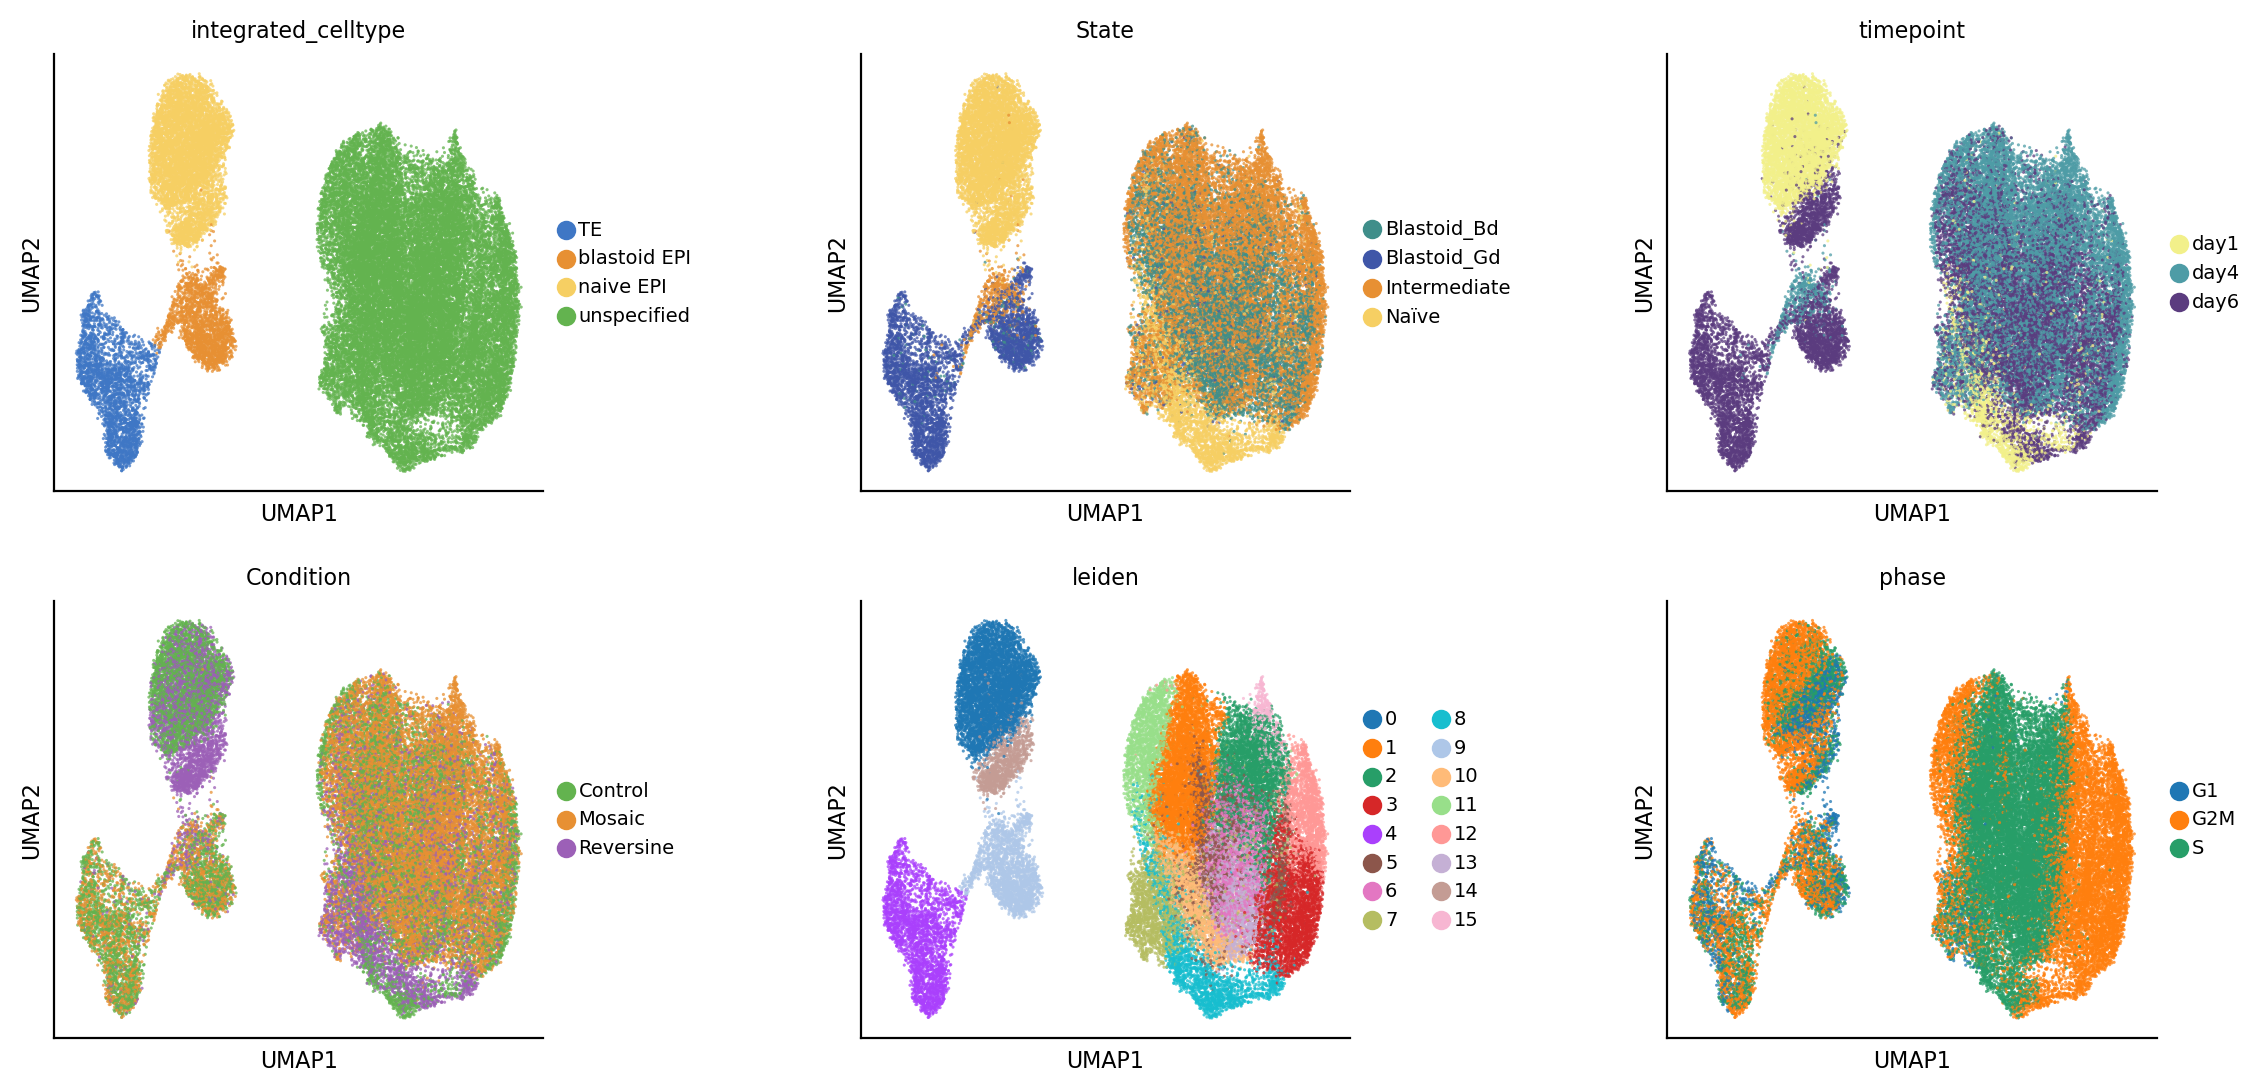

In [14]:
# -- Where do the unspecified cells actually sit?
idx = np.random.permutation(adata_sub.n_obs)

with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 100,
                     "axes.titlesize": 8, "legend.fontsize": 7, "axes.labelsize": 8}):
    sc.pl.umap(
        adata_sub[idx, :],
        color=["integrated_celltype", "State", "timepoint", "Condition", "leiden", "phase"],
        ncols=3, wspace=0.5, size=5, alpha=0.75,
        save="_trajectory_orientation.pdf",
    )

In [15]:
# -- TE vs amnion vs hypoblast discrimination.
#    TE-specific:      TACSTD2, CDX2, NR2F2, HAND1 (mural), GATA2
#    shared TE/amnion: TFAP2A, GATA3, KRT18, KRT7   <- do NOT call TE on these alone
#    amnion-specific:  ISL1, GABRP, VTCN1, IGFBP3, MSX2, POSTN
#    hypoblast/PrE:    SOX17, GATA4, PDGFRA, APOA1, RSPO3, COL4A1
lineage_markers = {
    "Naive hPSC":   ["KLF17", "DPPA5", "DNMT3L", "TBX3", "IL6ST", "DPPA3", "KHDC3L", "ALPP"],
    "EPI":          ["POU5F1", "NANOG", "SOX2", "GDF3", "TDGF1", "ARGFX"],
    "Post-imp EPI": ["FGF2", "NODAL", "SFRP2", "ZIC2", "CD24"],
    "TE specific":  ["TACSTD2", "CDX2", "NR2F2", "GATA2", "HAND1"],
    "TE shared":    ["TFAP2A", "TFAP2C", "GATA3", "KRT18", "KRT7"],
    "Polar TE/STB": ["SDC1", "GCM1", "CYP19A1", "MUC15", "DLX5"],
    "Amnion":       ["ISL1", "GABRP", "VTCN1", "IGFBP3", "MSX2", "POSTN"],
    "Hypoblast":    ["SOX17", "GATA4", "PDGFRA", "APOA1", "RSPO3", "COL4A1"],
    "Mesoderm":     ["APLNR", "CRABP2", "HAND2"],
}

# drop genes not in the object (same pattern as your annotation notebook)
filtered = {}
skipped = {}
for cat, genes in lineage_markers.items():
    present = [g for g in genes if g in adata_sub.var_names]
    absent = [g for g in genes if g not in adata_sub.var_names]
    if present:
        filtered[cat] = present
    if absent:
        skipped[cat] = absent

print("Skipped genes:")
for cat, genes in skipped.items():
    print(f"  {cat}: {genes}")

Skipped genes:


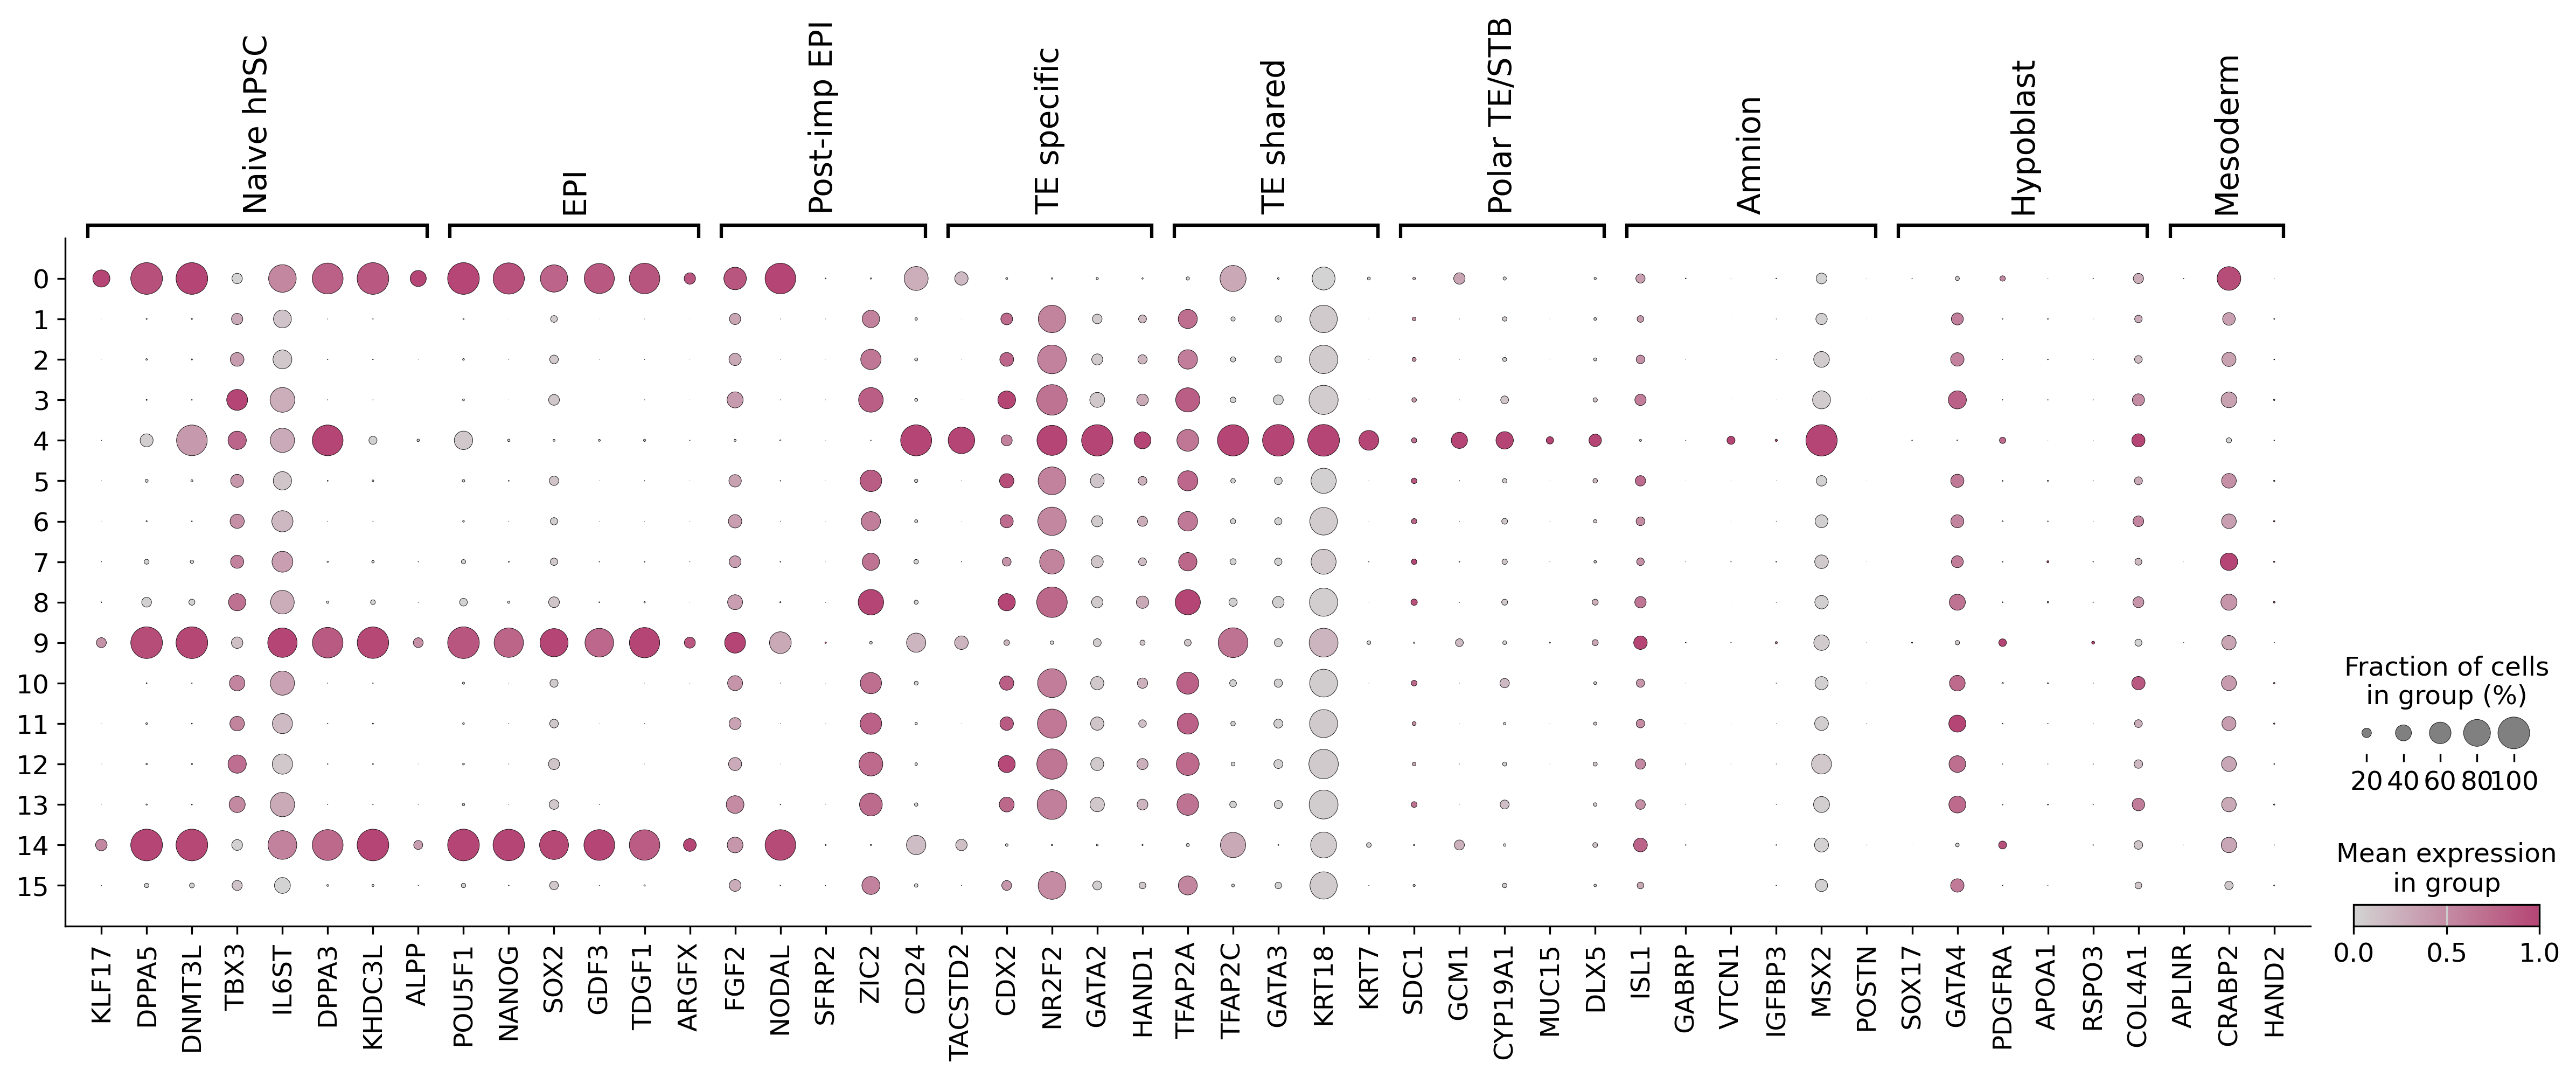

In [16]:
sc.settings.set_figure_params(dpi=150)

sc.pl.dotplot(
    adata_sub,
    groupby="leiden",
    var_names=filtered,
    standard_scale="var",
    cmap=grey_to_pink,
    save="_lineage_vs_offtarget.pdf",
)

In [17]:
# ============================================================================
# EDIT THIS CELL. Everything downstream depends on it.
#
# on_lineage_leiden : clusters forming the naive -> {EPI, TE} continuum,
#                     INCLUDING the intermediates currently in 'unspecified'
# off_target_leiden : amnion-like / mesoderm / anything not on the lineage
# ============================================================================

on_lineage_leiden = [
    # e.g. "0", "14",   # naive EPI
    #      "9",         # blastoid EPI
    #      "4",         # TE
    #      "2", "6",    # intermediates from 'unspecified' -- fill in from the dotplot
]
off_target_leiden = [
    # e.g. amnion-like, mesoderm-like clusters
]

assert on_lineage_leiden, "Fill in on_lineage_leiden from the dotplot above before continuing."
assert not set(on_lineage_leiden) & set(off_target_leiden), "A cluster is in both lists."

lin = adata_sub[adata_sub.obs["leiden"].isin(on_lineage_leiden)].copy()

print(f"{lin.n_obs} / {adata_sub.n_obs} cells kept "
      f"({100 * lin.n_obs / adata_sub.n_obs:.1f}%)")
print()
print(pd.crosstab(lin.obs["timepoint"], lin.obs["Condition"]))

AssertionError: Fill in on_lineage_leiden from the dotplot above before continuing.

In [19]:
lin = adata_sub

In [20]:
# -- Numeric time for OT. moscot wants this as an ordered category.
day_map = {"day1": 1, "day4": 4, "day6": 6}
lin.obs["day"] = lin.obs["timepoint"].map(day_map).astype(int)
lin.obs["day"] = lin.obs["day"].astype("category")
lin.obs["day"] = lin.obs["day"].cat.set_categories(sorted(day_map.values()), ordered=True)

print(lin.obs["day"].value_counts().sort_index())

day
1     6839
4    15714
6    16102
Name: count, dtype: int64


## 4. Rebuild the manifold on the lineage only

HVGs chosen across the whole object are dominated by whatever separates the
lineage from the off-target populations. Recompute them on the subset so the
variance you model is the variance that structures *this* continuum.

Note `batch_key="dataset"` in HVG selection: this only makes HVG selection
robust to sample-specific genes, it does **not** correct the embedding. That is
deliberate — see point 2 in the header.

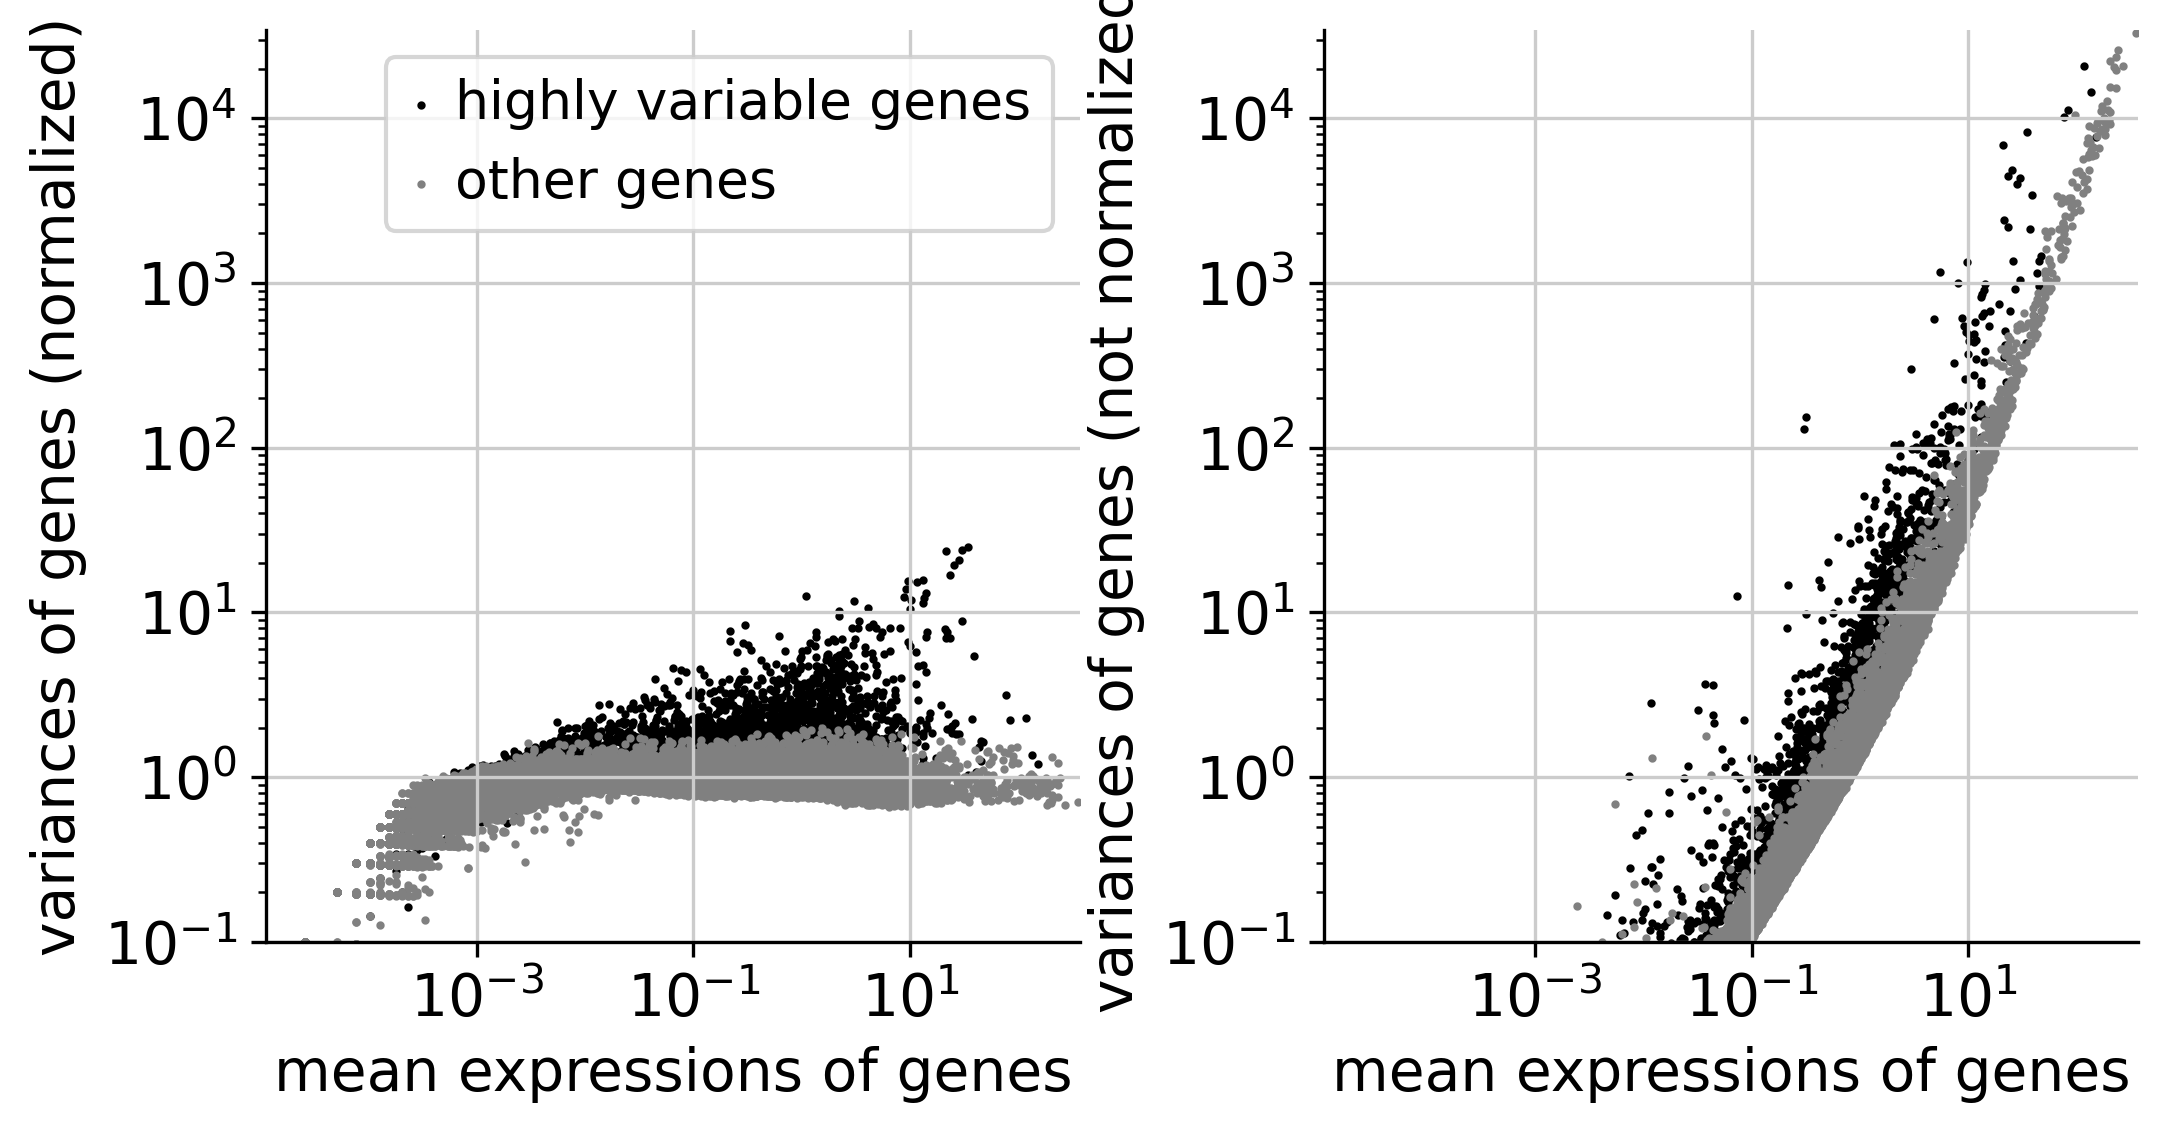

3000 HVGs


In [21]:
sc.pp.highly_variable_genes(
    lin,
    flavor="seurat_v3",
    n_top_genes=3000,
    layer="counts",
    batch_key="dataset",
    subset=False,
)

sc.pl.highly_variable_genes(lin, log=True)
print(f"{lin.var['highly_variable'].sum()} HVGs")

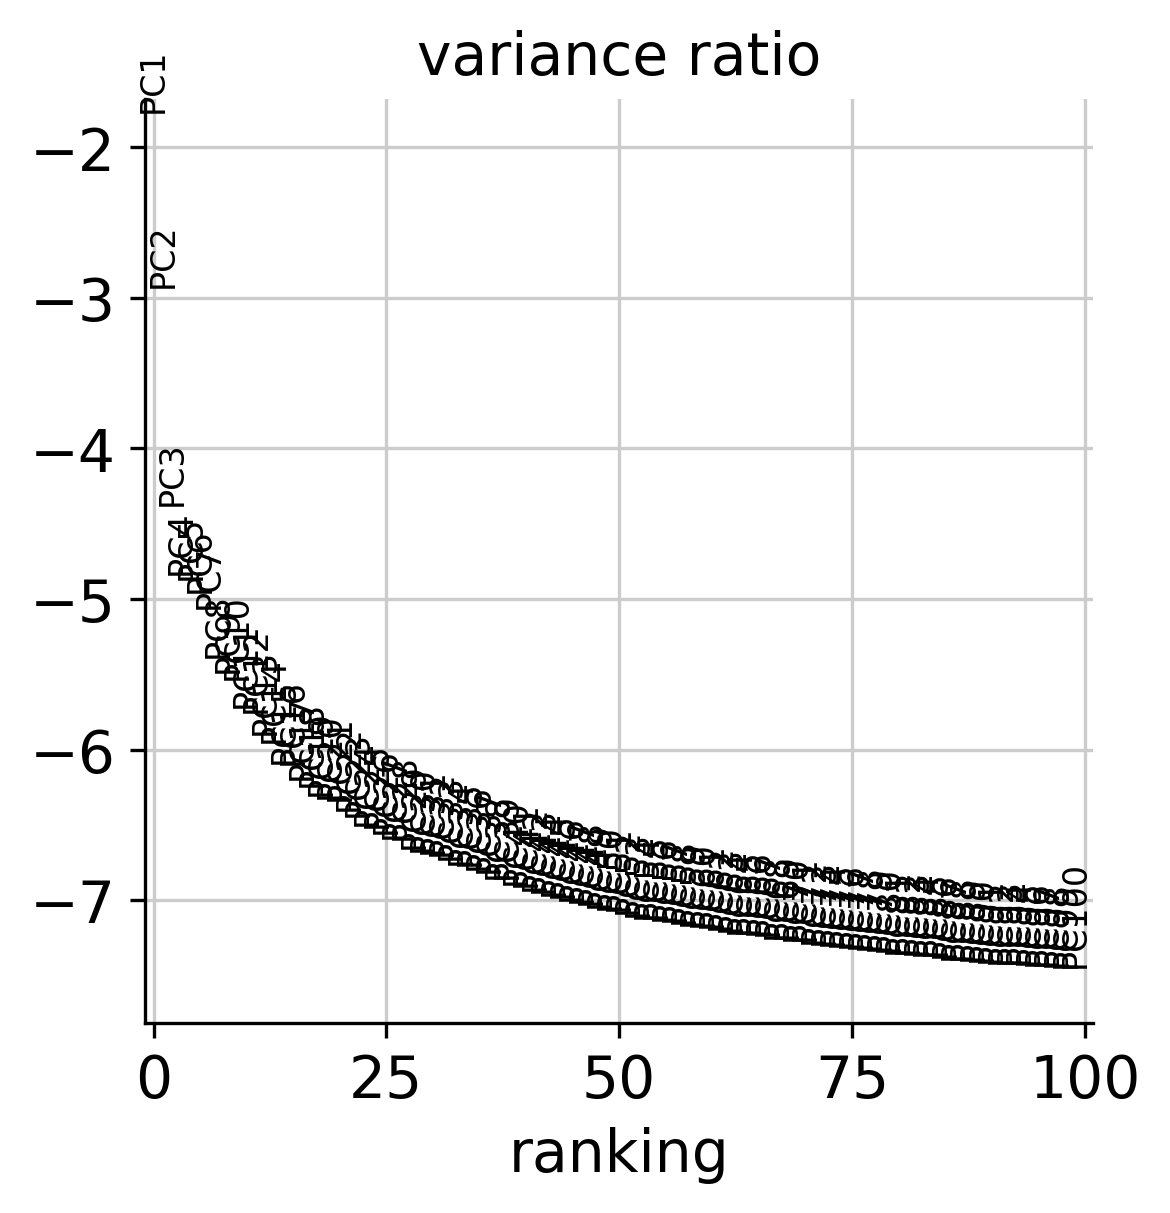

In [22]:
# -- Same scale-then-transfer pattern as your annotation notebook, so that
#    lin.X stays log-normalised (CellRank and gene-trend plots need that).
bdata = lin[:, lin.var["highly_variable"]].copy()
sc.pp.scale(bdata, max_value=10)
sc.tl.pca(bdata, n_comps=100, svd_solver="arpack")

lin.var["highly_variable"] = lin.var["highly_variable"].fillna(False)
lin.obsm["X_pca"] = bdata.obsm["X_pca"].copy()
lin.uns["pca"] = bdata.uns["pca"].copy()
lin.varm["PCs"] = np.zeros(shape=(lin.n_vars, 100))
lin.varm["PCs"][lin.var["highly_variable"].values] = bdata.varm["PCs"]

sc.pl.pca_variance_ratio(lin, n_pcs=100, log=True)
del bdata

In [23]:
N_PCS = 30          # revisit against the knee above
N_NEIGHBORS = 15

sc.pp.neighbors(lin, n_pcs=N_PCS, n_neighbors=N_NEIGHBORS, random_state=SEED)
sc.tl.umap(lin, min_dist=0.4, spread=1.0, random_state=SEED)
sc.tl.leiden(lin, resolution=1.0, key_added="leiden_lin", random_state=SEED)

lin.obsm["X_umap_lin"] = lin.obsm["X_umap"].copy()

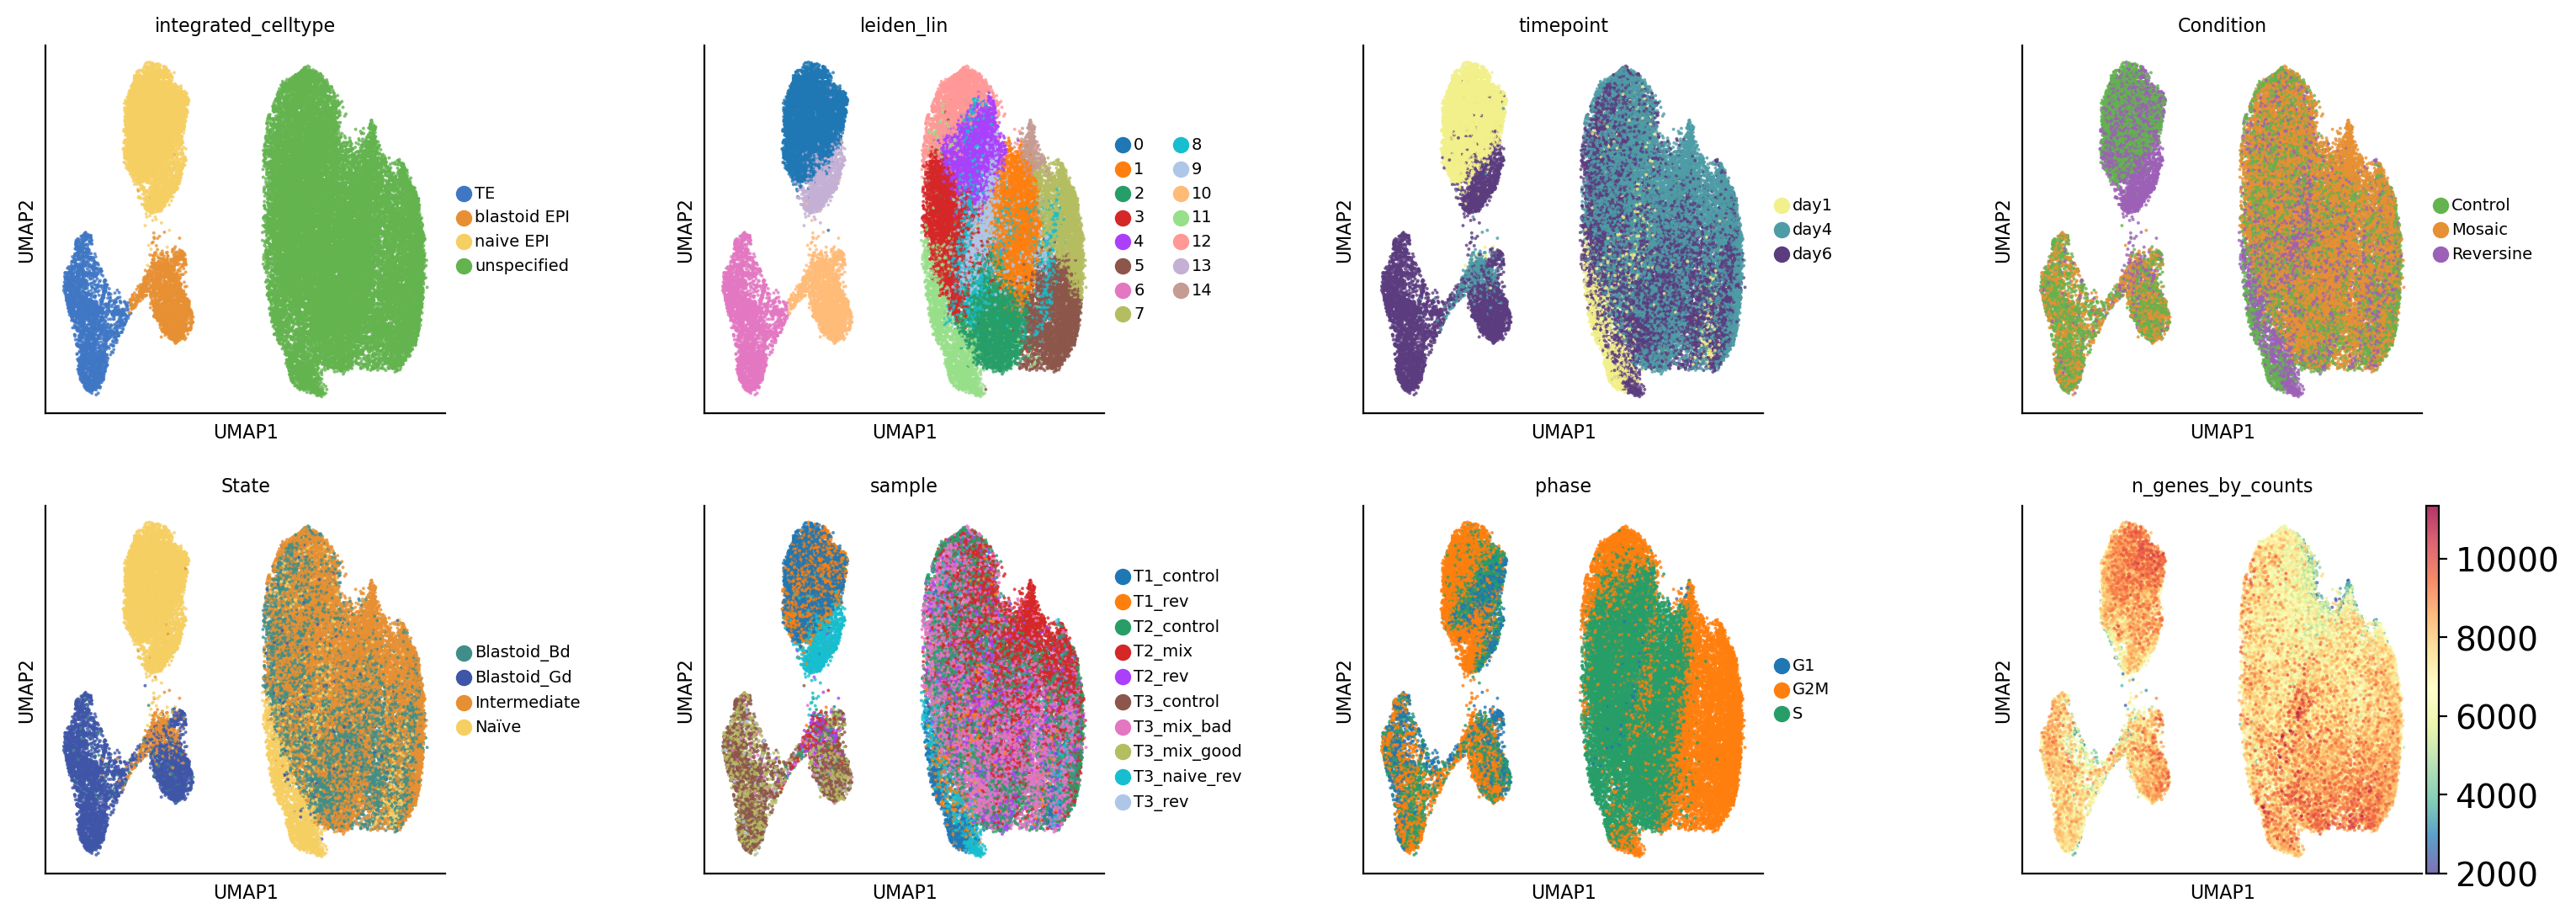

In [24]:
idx = np.random.permutation(lin.n_obs)

with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 100,
                     "axes.titlesize": 8, "legend.fontsize": 7, "axes.labelsize": 8}):
    sc.pl.umap(
        lin[idx, :],
        color=["integrated_celltype", "leiden_lin", "timepoint", "Condition",
               "State", "sample", "phase", "n_genes_by_counts"],
        ncols=4, wspace=0.5, size=8, alpha=0.8,
        save="_lineage_manifold.pdf",
    )

## 5. Confound checks

Three things can masquerade as differentiation on this manifold. Check them now,
because each has a different fix and all of them are cheap to test.

**Cell cycle.** Naive hPSCs divide fast. If `phase` structures DC1 you are
partly ordering cells by cycle, not by fate.

**Stress.** You already have `stress_score_vandenBrink`; dissociation stress
correlates with time-in-protocol and can mimic a trajectory endpoint.

**Chromosome dosage.** This is the one specific to your design. Reversine
produces aneuploidy, so affected cells carry a coordinated, chromosome-wide
shift in expression. If that signal is in your HVGs it will appear as a PC, and
cells will separate by karyotype rather than by fate. The check below scores each
cell on mean expression per chromosome arm and correlates those scores with the
leading PCs.

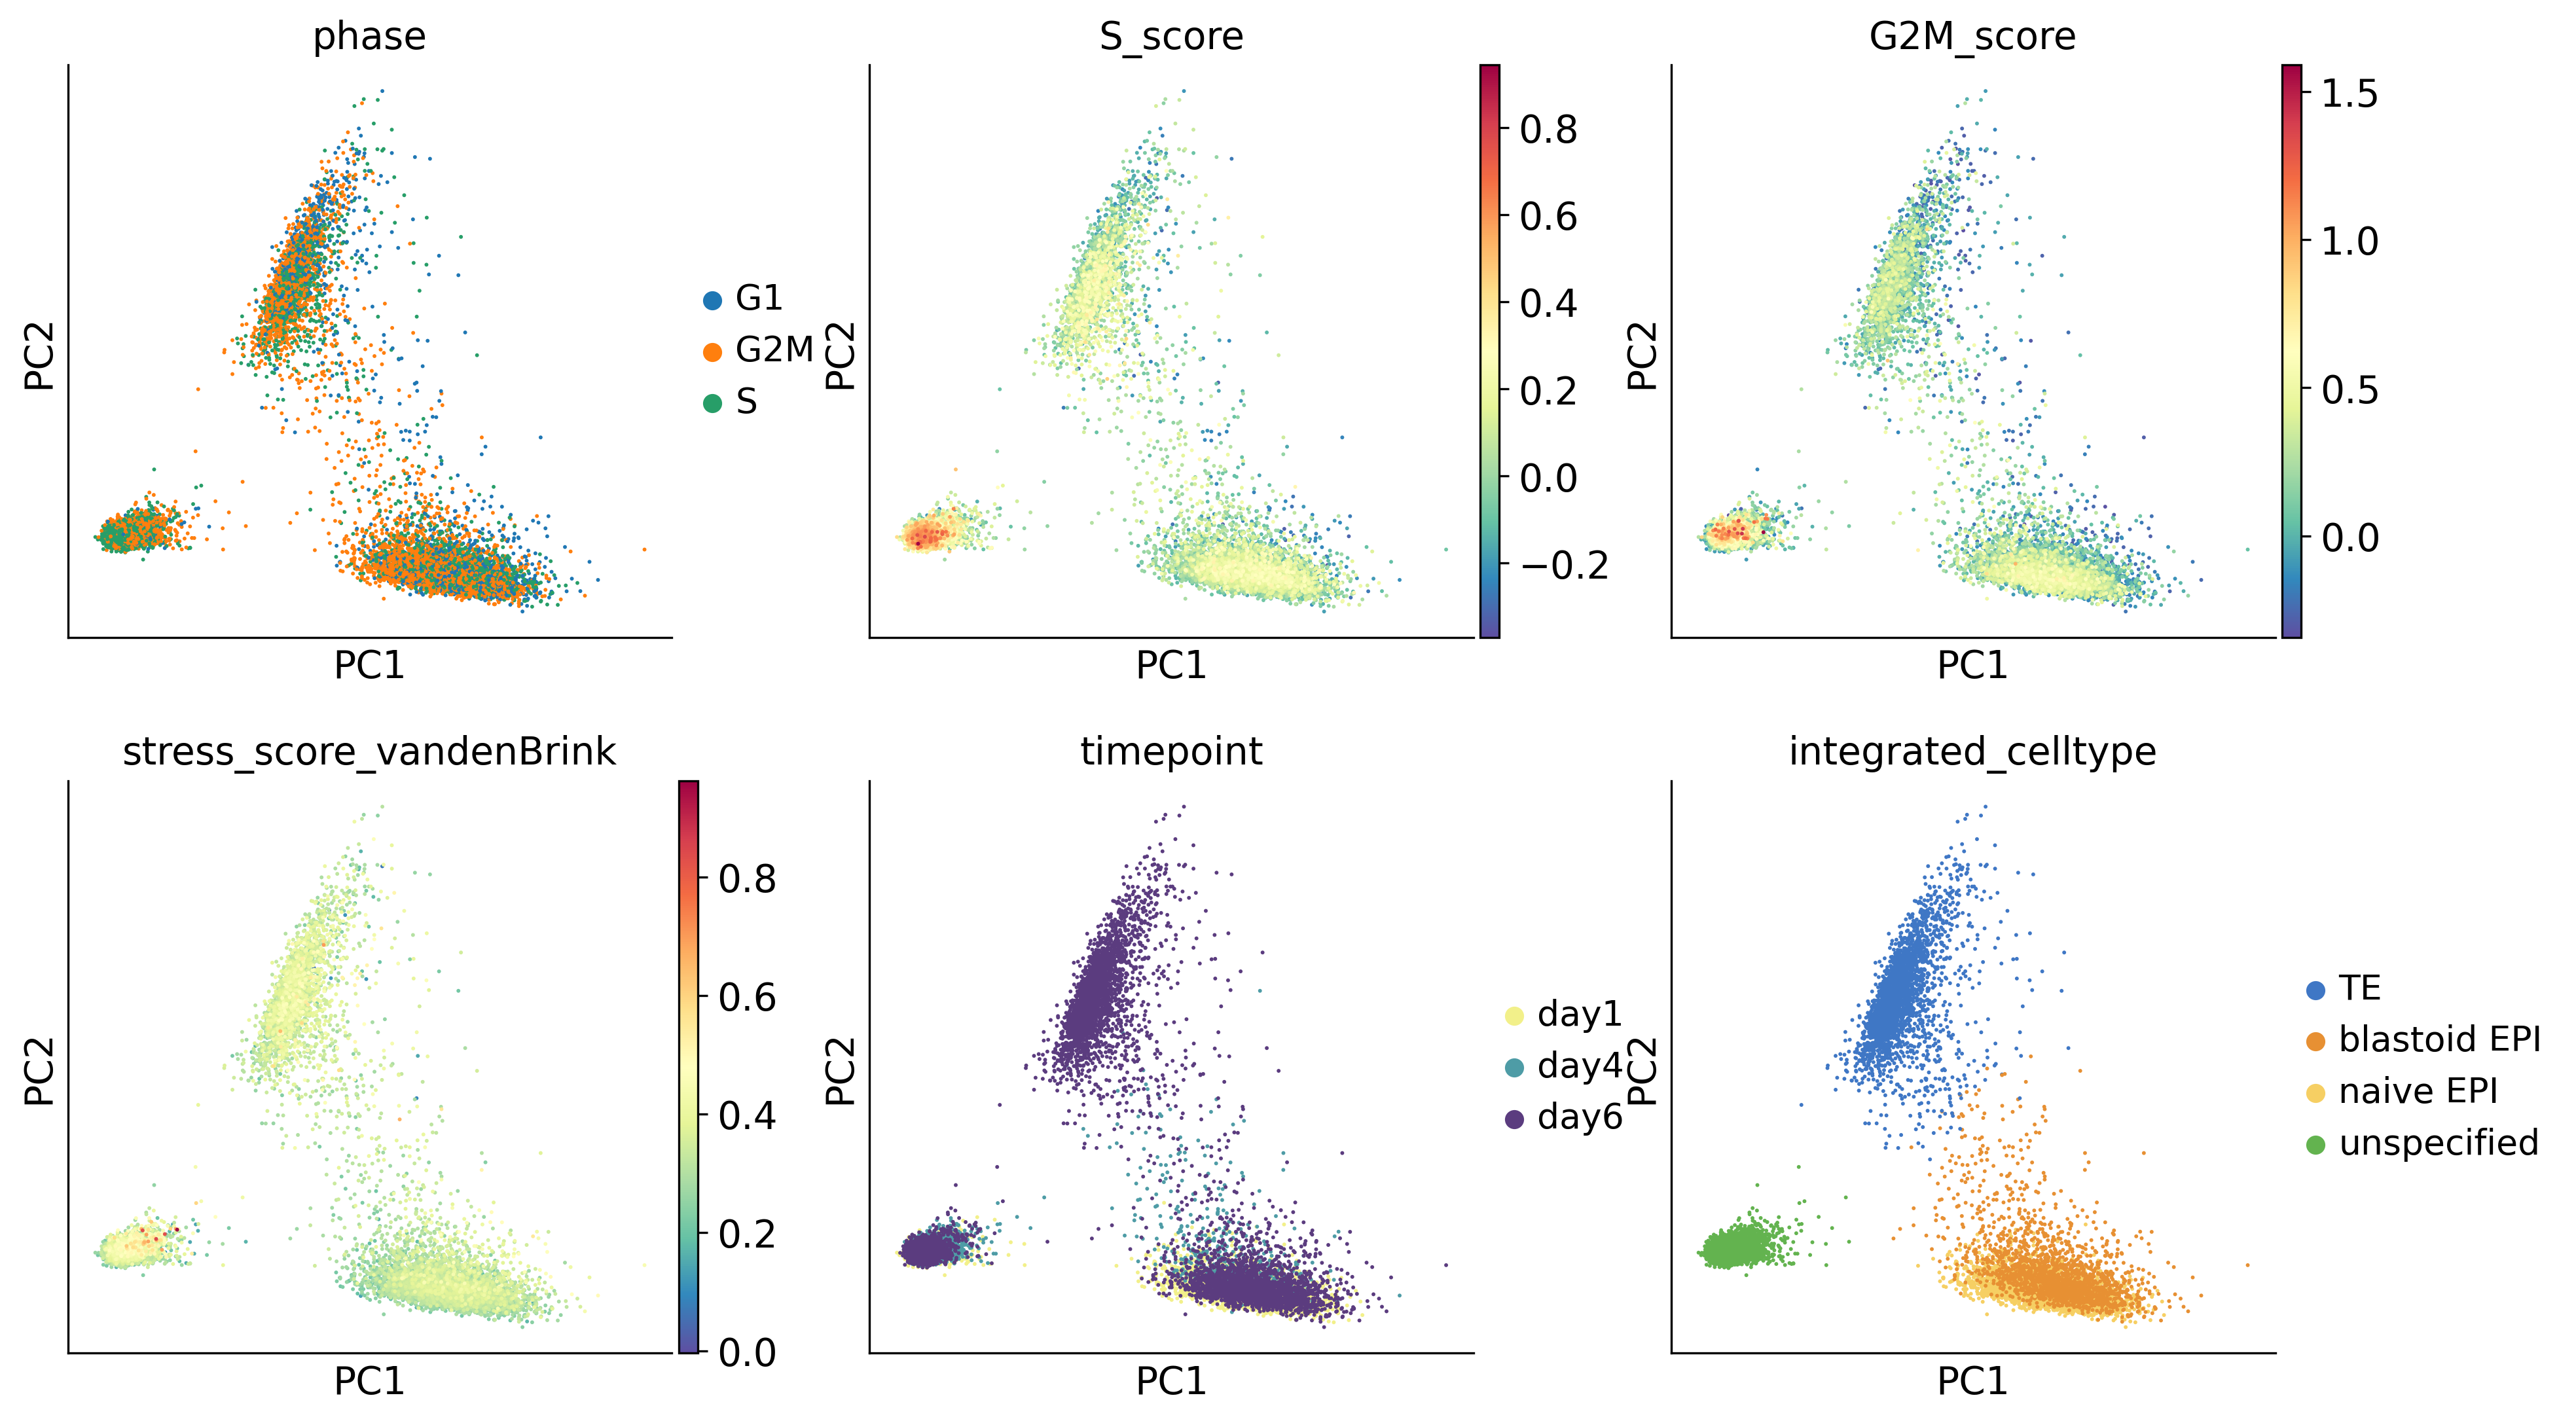

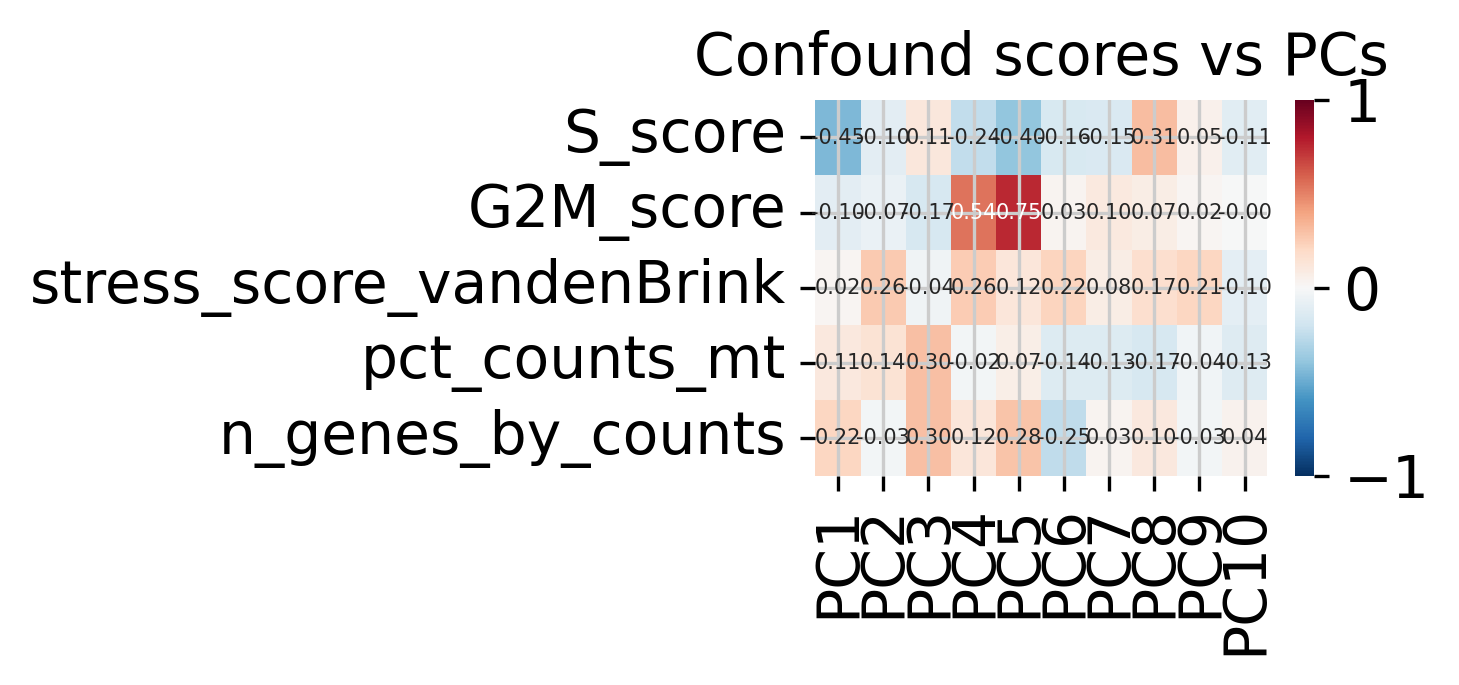

In [27]:
# -- Cell cycle and stress against the leading PCs
sc.pl.pca(lin, color=["phase", "S_score", "G2M_score", "stress_score_vandenBrink",
                      "timepoint", "integrated_celltype"],
          ncols=3, size=8, save="_confounds_pca.pdf")

# Correlation of scores with the first 10 PCs
scores = lin.obs[["S_score", "G2M_score", "stress_score_vandenBrink",
                  "pct_counts_mt", "n_genes_by_counts"]].astype(float)
pcs = pd.DataFrame(lin.obsm["X_pca"][:, :10],
                   columns=[f"PC{i+1}" for i in range(10)],
                   index=lin.obs_names)

corr = pd.concat([scores, pcs], axis=1).corr().loc[scores.columns, pcs.columns]

fig, ax = plt.subplots(figsize=(5, 2.5), dpi=150)
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 5}, ax=ax)
ax.set_title("Confound scores vs PCs")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confound_pc_correlation.pdf"), bbox_inches="tight")
plt.show()

In [28]:
# -- Chromosome dosage check.
#    Needs a gene -> chromosome map. If lin.var already has a 'chromosome'
#    column from your reference, use it; otherwise pull one from the
#    cellranger GTF or pybiomart. Adjust the path.
GTF_PATH = None   # e.g. "/lustre/.../refdata-gex-GRCh38-2024-A/genes/genes.gtf"

if "chromosome" in lin.var.columns:
    gene2chr = lin.var["chromosome"]
elif GTF_PATH is not None:
    import re
    rows = {}
    with open(GTF_PATH) as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            f = line.split("\t")
            if f[2] != "gene":
                continue
            m = re.search(r'gene_name "([^"]+)"', f[8])
            if m:
                rows.setdefault(m.group(1), f[0])
    gene2chr = pd.Series(rows).reindex(lin.var_names)
    lin.var["chromosome"] = gene2chr
else:
    gene2chr = None
    print("No chromosome annotation available -- set GTF_PATH to run this check.")

No chromosome annotation available -- set GTF_PATH to run this check.


In [29]:
if gene2chr is not None:
    chroms = [f"chr{c}" if not str(c).startswith("chr") else str(c)
              for c in list(range(1, 23)) + ["X"]]
    gene2chr_norm = gene2chr.astype(str).apply(
        lambda c: c if c.startswith("chr") else f"chr{c}"
    )

    # Score each cell on each chromosome, using only expressed genes
    for chrom in chroms:
        genes = lin.var_names[gene2chr_norm == chrom].tolist()
        genes = [g for g in genes if g in lin.var_names]
        if len(genes) < 50:
            continue
        sc.tl.score_genes(lin, gene_list=genes, score_name=f"score_{chrom}",
                          ctrl_size=min(50, len(genes)), random_state=SEED)

    score_cols = [c for c in lin.obs.columns if c.startswith("score_chr")]

    # Do chromosome scores track the leading PCs (bad) or the Condition (expected)?
    chr_scores = lin.obs[score_cols].astype(float)
    corr_chr = pd.concat([chr_scores, pcs], axis=1).corr().loc[score_cols, pcs.columns]

    fig, ax = plt.subplots(figsize=(5, 6), dpi=150)
    sns.heatmap(corr_chr, cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
                annot=False, ax=ax)
    ax.set_title("Chromosome dosage scores vs PCs")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "chr_dosage_vs_pcs.pdf"), bbox_inches="tight")
    plt.show()

    # And per condition -- this is the sanity check that reversine did something
    print(lin.obs.groupby("Condition", observed=True)[score_cols].mean().T.round(3))

**How to read that.** Chromosome scores differing by `Condition` is expected and
is confirmation that reversine worked. Chromosome scores correlating strongly
(|r| > ~0.3) with PC1/PC2 is the problem case: your leading variance is dosage,
not fate. If that happens, rebuild the manifold excluding the affected
chromosomes from the HVG set and confirm the branch structure survives:

```python
## bad_chr = ["chr7", "chr12"]                      # whichever came out
## mask = ~lin.var["chromosome"].astype(str).isin(bad_chr)
## lin.var["highly_variable"] = lin.var["highly_variable"] & mask.values
# then re-run the PCA / neighbours cells in section 4
```

If the branches disappear when you exclude those chromosomes, the branches were
dosage. That is a real result, but a different one from a fate bias, and it
needs saying explicitly rather than being reported as differentiation.

## 6. Root cell

Pick the root from biology first, then take the extreme cell within that pool
rather than an arbitrary member. `DC0` in a diffusion map is trivial (constant),
so the ordering axis is `DC1`.

Restrict the candidate pool to **naive EPI at day1 in Control**: that is the
protocol's actual starting material, and using a Control cell keeps the root
independent of the reversine perturbation.

In [37]:
sc.tl.diffmap(lin, n_comps=15)

root_pool = (
    (lin.obs["integrated_celltype"] == "naive EPI")
    & (lin.obs["timepoint"] == "day1")
    & (lin.obs["Condition"] == "Control")
).values

print(f"{root_pool.sum()} candidate root cells")
assert root_pool.sum() > 0, "No naive EPI day1 Control cells -- relax the criteria."

dc1 = lin.obsm["X_diffmap"][:, 1]

# Orient DC1 so that the naive pool sits at the LOW end, then take the extreme.
naive_mean = dc1[root_pool].mean()
other_mean = dc1[~root_pool].mean()
sign = 1.0 if naive_mean < other_mean else -1.0

cand = np.where(root_pool)[0]
root_idx = cand[np.argmax(sign * dc1[cand])]
root_cell = lin.obs_names[root_idx]

print("root cell:", root_cell)
print(lin.obs.loc[root_cell, ["sample", "timepoint", "Condition", "State",
                              "integrated_celltype", "leiden_lin", "phase"]])

3145 candidate root cells
root cell: 5414
sample                 T1_control
timepoint                    day1
Condition                 Control
State                       Naïve
integrated_celltype     naive EPI
leiden_lin                      0
phase                         G2M
Name: 5414, dtype: object


In [38]:
# -- Verify the root is actually naive: high naive markers, low mature markers
check_genes = [g for g in ["KLF17", "DPPA5", "DNMT3L", "POU5F1", "NANOG",
                           "GATA3", "CDX2", "TACSTD2", "KRT7", "SOX17"]
               if g in lin.var_names]

root_expr = pd.Series(
    np.asarray(lin[root_cell, check_genes].X.todense()).ravel()
    if hasattr(lin.X, "todense") else lin[root_cell, check_genes].X.ravel(),
    index=check_genes, name="root",
)
mean_expr = pd.Series(
    np.asarray(lin[:, check_genes].X.mean(axis=0)).ravel(),
    index=check_genes, name="dataset_mean",
)
pd.concat([root_expr, mean_expr], axis=1).round(2)

,root,dataset_mean
KLF17,0.17,0.02
DPPA5,3.58,0.72
DNMT3L,2.53,0.60
POU5F1,2.78,0.58
NANOG,0.83,0.20
GATA3,0.00,0.17
CDX2,0.00,0.08
TACSTD2,0.17,0.05
KRT7,0.00,0.02
SOX17,0.00,0.00


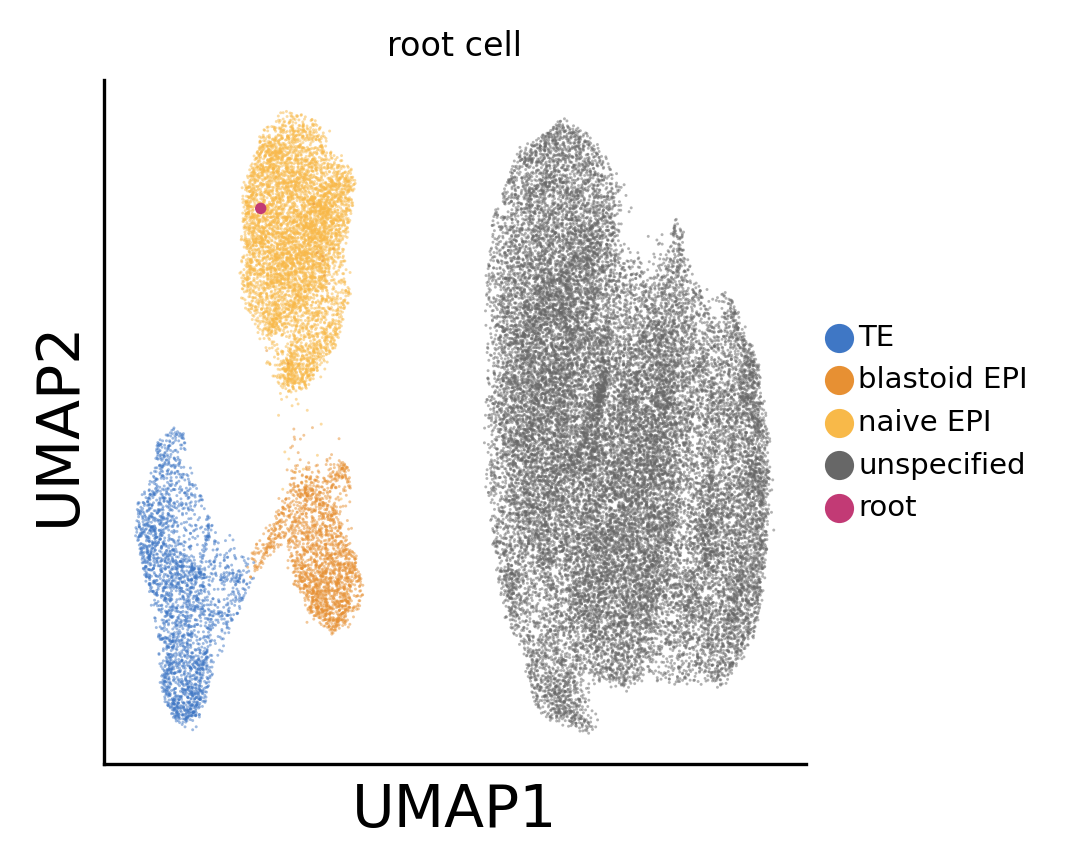

In [39]:
lin.obs["is_root"] = pd.Categorical(
    np.where(lin.obs_names == root_cell, "root", "other"),
    categories=["other", "root"],
)


with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150,
                     "axes.titlesize": 8, "legend.fontsize": 7}):
    
    ax = sc.pl.umap(lin, color="integrated_celltype", size=2, alpha=0.5,
                    palette=celltype_colors, show=False)
    sc.pl.umap(lin[[root_cell]], color="is_root", ax=ax, size=30,
               palette={"other": "#D3D3D3", "root": "#C23A75"},
               title="root cell", save="_root_cell.pdf")

In [40]:
print(pd.DataFrame({"DC1": lin.obsm["X_diffmap"][:, 1]})
      .groupby(lin.obs["integrated_celltype"].values).mean())

                   DC1
TE            0.000009
blastoid EPI  0.000009
naive EPI     0.000009
unspecified  -0.005983


## 8. Optimal transport across time points, per condition

Now the main trajectory. `TemporalProblem` couples adjacent time points by
optimal transport in the PCA space, and those couplings become the transition
matrix.

**Why a loop over conditions.** With `policy="sequential"` moscot couples every
day1 cell to every day4 cell in the object. Across conditions that means
matching a Control day1 cell to a Reversine day4 cell — a transition that never
happened. Fitting separately per condition keeps each coupling within its own
experiment.

**Why `score_genes_for_marginals` matters.** By default OT treats every cell as
carrying equal mass, so a population that simply proliferated faster looks like
it *differentiated into* the next time point. Scoring proliferation and apoptosis
lets moscot set unequal marginals. With naive hPSCs dividing quickly this is not
optional.

**Unbalancedness.** `tau_a`/`tau_b` < 1 allow mass to be created/destroyed, which
you want here because cells die and divide between day1 and day6. Start at
`tau_a=0.95, tau_b=0.999` and check the growth rates look sane.

In [63]:
conditions = [c for c in ["Control", "Mosaic", "Reversine"]
              if c in lin.obs["Condition"].unique()]

# The reference trajectory is fitted on Control; the others are for comparison.
REFERENCE_CONDITION = "Control"
print("conditions:", conditions, "| reference:", REFERENCE_CONDITION)

conditions: ['Control', 'Mosaic', 'Reversine'] | reference: Control


In [64]:
problems = {}
kernels = {}

for cond in conditions:
    print(f"\n{'=' * 60}\n{cond}\n{'=' * 60}")
    sub = lin[lin.obs["Condition"] == cond].copy()

    n_per_day = sub.obs["day"].value_counts().sort_index()
    print(n_per_day)
    if (n_per_day < 200).any():
        print("  WARNING: fewer than 200 cells at some time point -- "
              "couplings will be poorly conditioned.")
    if n_per_day.gt(0).sum() < 2:
        print("  SKIPPING: needs at least two time points.")
        continue

    tp = TemporalProblem(sub)

    # unequal marginals from proliferation / apoptosis signatures
    tp = tp.score_genes_for_marginals(
        gene_set_proliferation="human",
        gene_set_apoptosis="human",
    )

    tp = tp.prepare(time_key="day", joint_attr="X_pca", policy="sequential")
    tp = tp.solve(epsilon=1e-3, tau_a=0.95, tau_b=0.999, scale_cost="mean")

    problems[cond] = tp
    print("  solved:", list(tp.solutions.keys()))


Control
day
1    4052
4    6511
6    2355
Name: count, dtype: int64
INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(6511, 2355)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(4052, 6511)].                                  
  solved: [(4, 6), (1, 4)]

Mosaic
day
4     6495
6    10878
Name: count, dtype: int64
INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(6495, 10878)].                                 
  solved: [(4, 6)]

Reversine
day
1    2787
4    2708
6    2869
Name: count, dtype: int64
INFO     Solving `2` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared

KeyError: 'Could not find key prior_growth_rates in .var_names or .obs.columns.'

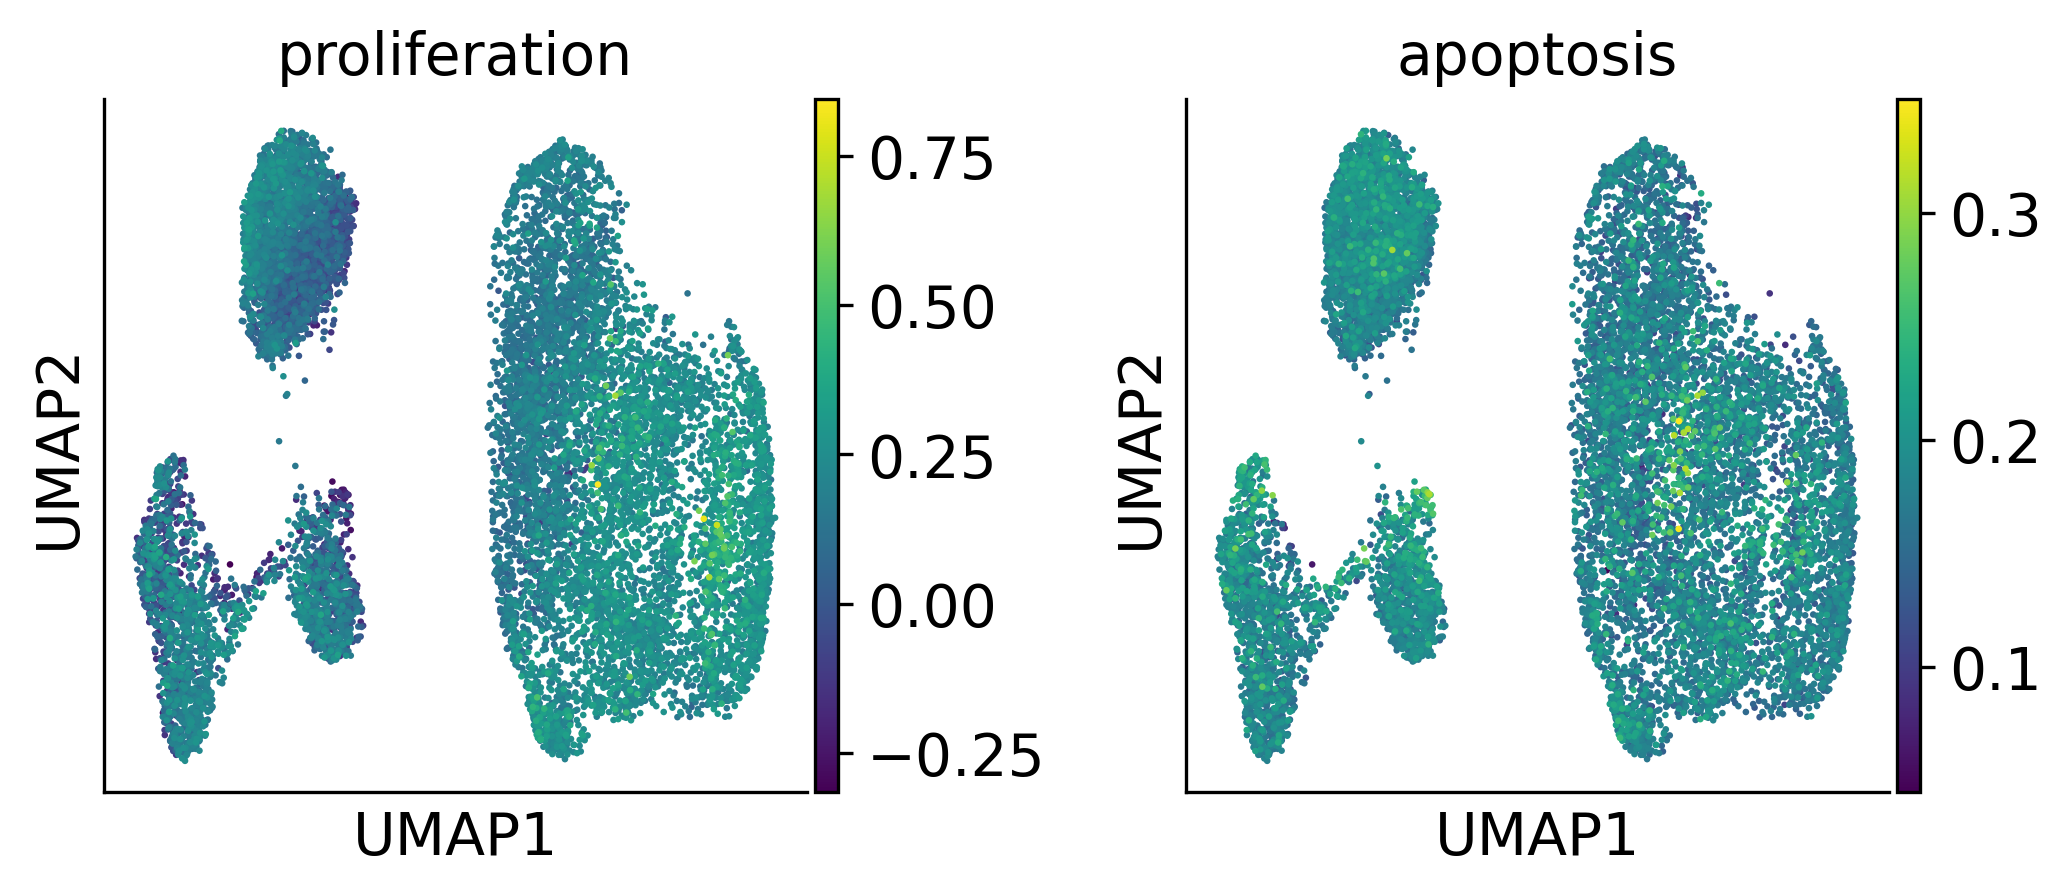

In [65]:
# -- Inspect the growth rates. Cells with high prior growth should be the
#    proliferative ones; posterior rates that are wildly bimodal usually mean
#    epsilon or tau needs adjusting.
cond = REFERENCE_CONDITION
tp = problems[cond]

with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    sc.pl.umap(tp.adata, color=["proliferation", "apoptosis",
                                "prior_growth_rates", "posterior_growth_rates"],
               ncols=4, size=10, color_map="viridis", wspace=0.4,
               save=f"_growth_rates_{cond}.pdf")

In [66]:
# -- Coarse cell-type transitions between adjacent days, reference condition.
#    This is the single most informative diagnostic: naive should flow into
#    EPI and TE, and mature states should not flow backwards.
order = [c for c in ["naive EPI", "blastoid EPI", "TE", "unspecified"]
         if c in lin.obs["integrated_celltype"].unique()]

days_present = sorted(problems[REFERENCE_CONDITION].adata.obs["day"].cat.categories)
for src, tgt in zip(days_present[:-1], days_present[1:]):
    ct = problems[REFERENCE_CONDITION].cell_transition(
        source=src, target=tgt,
        source_groups={"integrated_celltype": order},
        target_groups={"integrated_celltype": order},
        forward=True,
    )
    print(f"\nday {src} -> day {tgt}")
    display(ct.round(3))


day 1 -> day 4


,naive EPI,blastoid EPI,TE,unspecified
naive EPI,0.041,0.925,0.035,0.0
blastoid EPI,0.000,1.000,0.000,0.0
unspecified,0.000,0.000,0.000,1.0



day 4 -> day 6


,naive EPI,blastoid EPI,TE,unspecified
naive EPI,0.007,0.993,0.000,0.000
blastoid EPI,0.003,0.905,0.092,0.000
TE,0.000,0.001,0.999,0.000
unspecified,0.000,0.000,0.614,0.386


## 9. RealTimeKernel

The OT couplings only describe transitions *between* time points. With three time
points you have just two couplings, so within-timepoint structure has to come
from somewhere else. Two ingredients are blended in:

- `self_transitions="all"` plus `conn_weight=0.2` mixes in a KNN connectivity
  kernel, giving transitions among cells at the same day.
- `threshold="auto_local"` sparsifies the dense entropic-regularised maps, which
  is what makes the downstream eigendecomposition tractable.

A Palantir-derived `PseudotimeKernel` is then averaged in at low weight. This is
belt-and-braces: with only two couplings, a pure OT kernel can be brittle, and
the pseudotime provides a smooth within-timepoint direction.

In [67]:
from cellrank.kernels import RealTimeKernel, ConnectivityKernel, PseudotimeKernel

for cond, tp in problems.items():
    print(f"\n--- {cond}")
    rtk = RealTimeKernel.from_moscot(tp, time_key="day", policy="sequential")
    rtk = rtk.compute_transition_matrix(
        self_transitions="all",
        conn_weight=0.2,
        threshold="auto_local",
        conn_kwargs=dict(use_rep="X_pca", n_neighbors=15,
                         metric="cosine", random_state=SEED),
    )
    kernels[cond] = rtk
    print(rtk)


--- Control


TypeError: cellrank.kernels._real_time_kernel.RealTimeKernel() got multiple values for keyword argument 'time_key'